<a href="https://colab.research.google.com/github/darun3/newrepo/blob/newbranch/ML_HW_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
######################
# Set-up for each question
######################
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('hw2data1.txt', delimiter=',')
X = data[:, 0]  # Population
y = data[:, 1]  # Profit

#column of ones to X (the intercept term)
intercept_X = np.column_stack((np.ones(len(X)), X))

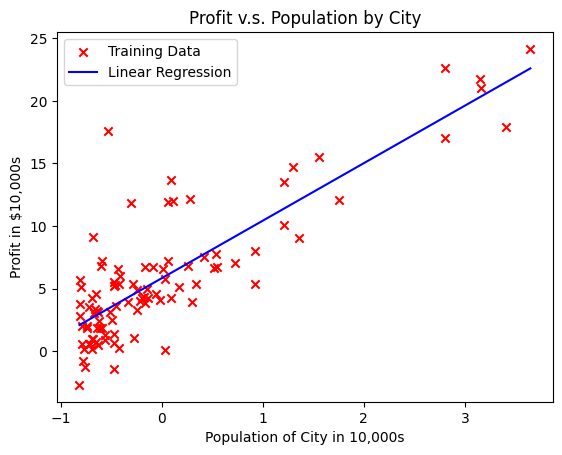

Optimal parameters: Intercept = 5.84, Slope = 4.59


In [3]:
######################
# Question 1.1 - Linear Regression
######################


#closed-form solution
theta = np.linalg.inv(intercept_X.T @ intercept_X) @ intercept_X.T @ y

#coefficients
intercept, slope = theta

#visualization
plt.scatter(X, y, color='red', marker='x', label='Training Data')
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Profit in $10,000s')

#plot the regression line
x_values = np.array([min(X), max(X)])
plt.plot(x_values, intercept + slope * x_values, 'b-', label='Linear Regression')

plt.title('Profit v.s. Population by City')
plt.legend()
plt.show()

print(f"Optimal parameters: Intercept = {intercept:.2f}, Slope = {slope:.2f}")


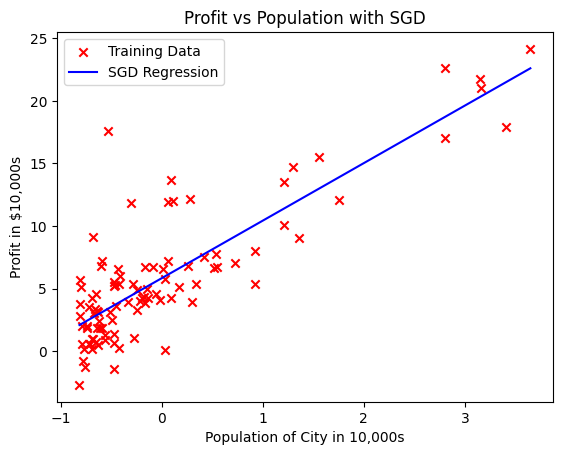

In [6]:
######################
# Question 1.2 - Linear Regression w/ SGD
######################


#intercept, slope
theta = np.zeros(2)

#hyperparameters
alpha = 0.001
epochs = 1000

for epoch in range(epochs):
     shuffled_indices = np.random.permutation(len(intercept_X)) #shuffle data avoids cycles
     shuffled_X = intercept_X[shuffled_indices]
     shuffled_y = y[shuffled_indices]

     #iterating over each sample
     for x_i, y_i in zip(shuffled_X, shuffled_y):
         prediction = np.dot(x_i, theta)
         error = prediction - y_i
         gradient = error * x_i  # Gradient for SGD
         theta -= alpha * gradient  # Update parameters

 #y_pred_sgd = intercept_X @ theta

 #visualization
plt.scatter(X, y, color='red', marker='x', label='Training Data')
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Profit in $10,000s')

 #plot
x_values = np.array([X.min(), X.max()])
y_values = theta[0] + theta[1] * x_values
plt.plot(x_values, y_values, 'b-', label='SGD Regression')

plt.title('Profit vs Population with SGD')
plt.legend()
plt.show()

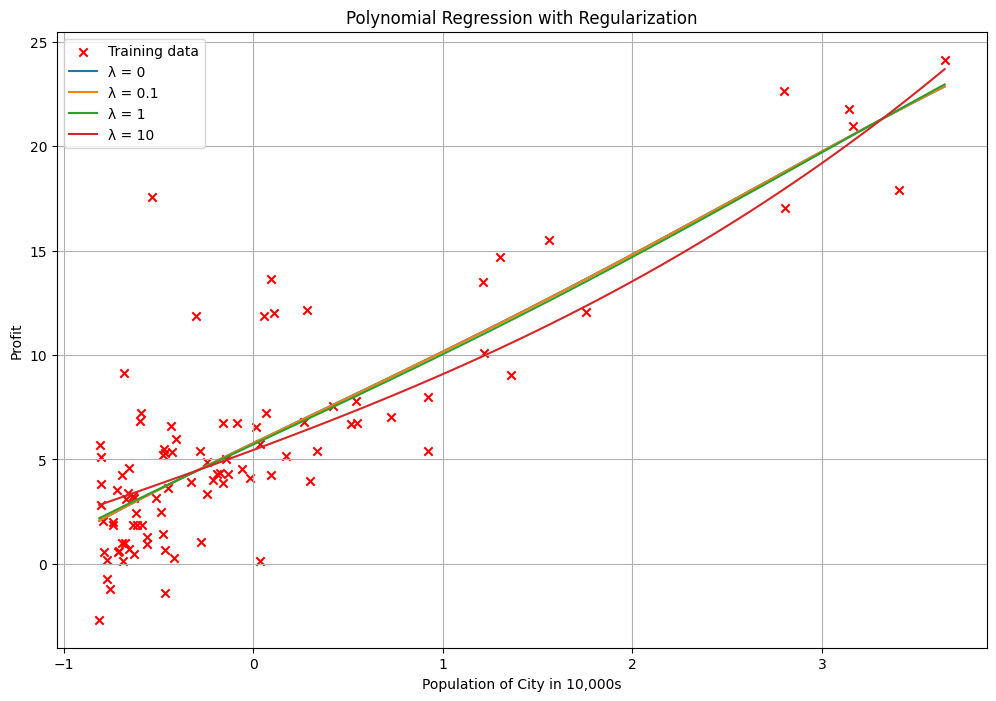

Learned parameters for different λ values:

λ = 0:
[ 5.7957  4.3895 -0.2938  1.1389 -0.6288]

λ = 0.1:
[ 5.7957  4.3757 -0.2635  1.0994 -0.6078]

λ = 1:
[ 5.7956  4.2544 -0.0511  0.8435 -0.4615]

λ = 10:
[5.7949e+00 3.3644e+00 4.9710e-01 5.4720e-01 1.9000e-03]


In [7]:
######################
# Question 1.3 - Linear Regression w/ SGD
######################

#polynomial feature expansion
def poly_features(x, degree):
    m = len(x)
    X_poly = np.ones((m, degree + 1))  #column of ones first (for theta[0])
    for d in range(1, degree + 1):
        X_poly[:, d] = x ** d
    return X_poly

#normalization
def normalize_features(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_norm = (X - mean) / std
    return X_norm, mean, std

#SGD with regularization implementation
def sgd_regression(X, y, theta, alpha, num_epochs, lambda_reg):
    m = len(y)

    for epoch in range(num_epochs):
        for i in range(m):
            xi = X[i, :].reshape(1, -1)
            yi = y[i]

            gradient = (xi @ theta - yi) * xi.T

            gradient = np.clip(gradient, -1e5, 1e5) #prevent overflow

            #regulatization
            theta[1:] -= alpha * (gradient[1:] + (lambda_reg/m) * theta[1:])
            theta[0] -= alpha * gradient[0]  #don't use for theta[0]

    return theta

X = data[:, 0].reshape(-1, 1)
y = data[:, 1].reshape(-1, 1)

#hyperparameters
degree = 4
alpha = 0.001
epochs = 1000
lambda_values = [0, 0.1, 1, 10]

X_poly = poly_features(X.flatten(), degree)

#normalize (w/o intercept)
X_poly[:, 1:], mean, std = normalize_features(X_poly[:, 1:])

plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='red', marker='x', label='Training data')

#prediction
x_range = np.linspace(X.min(), X.max(), 100)
X_poly_plot = poly_features(x_range, degree)

X_poly_plot[:, 1:] = (X_poly_plot[:, 1:] - mean) / std #normalize predicton

#training
theta_dict = {} #create dict to store the theta values based on sgd
for lambda_reg in lambda_values:
  #for each lambda reset theta
    theta_init = np.zeros((degree + 1, 1))
    theta = sgd_regression(X_poly, y, theta_init, alpha, epochs, lambda_reg)
    theta_dict[lambda_reg] = theta

    y_pred = X_poly_plot @ theta
    plt.plot(x_range, y_pred, label=f'λ = {lambda_reg}')

plt.xlabel('Population of City in 10,000s')
plt.ylabel('Profit')
plt.title('Polynomial Regression with Regularization')
plt.legend()
plt.grid(True)
plt.show()

#show learned parameters (results)
print("Learned parameters for different λ values:")
for lambda_reg, theta in theta_dict.items():
    print(f"\nλ = {lambda_reg}:")
    print(np.round(theta.flatten(), 4))